In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
from dataclasses import dataclass
from abc import ABC, abstractmethod
from typing import List, Tuple, Set

In [15]:
class MDP(ABC):
    """
    Abstract Base Class for MDPs in this project.
    Ensures compatibility with LSTDQAgent, PSRLAgent, etc.
    """
    
    def __init__(self):
        self.num_states: int = 0
        self.num_actions: int = 0
        self.branching_factor: int = 0
        self.depth: int = 0
        
        # For analytical agents (Oracle/PSRL)
        # These should be populated by the child class if possible
        self.P: np.ndarray = None  # Shape: [S, A, S]
        self.R: np.ndarray = None  # Shape: [S] (Mean rewards)

    @abstractmethod
    def step(self, state: int, action: int) -> Tuple[int, float, bool]:
        """
        Execute one step in the environment.
        Returns: (next_state, reward, done)
        """
        pass

    @abstractmethod
    def get_valid_actions(self, state: int) -> List[int]:
        """Return list of valid action indices for a given state."""
        pass

    @abstractmethod
    def is_leaf(self, state: int) -> bool:
        """
        Return True if the state is terminal/leaf.
        Used by agents to determine when to stop an episode or update posteriors.
        """
        pass

In [16]:
class ChainMDP(MDP):
    """
    Deep Sea / Chain MDP implementation.
    """
    def __init__(self, length: int = 12, reward_noise_std: float = 1.0):
        super().__init__()
        self.length = length
        self.num_states = length
        self.num_actions = 2
        self.branching_factor = 2
        self.depth = length
        self.reward_noise_std = reward_noise_std
        self.fail_prob = 1.0 / length
        
        # Pre-compute true dynamics for Oracle agents
        self.P = np.zeros((self.num_states, self.num_actions, self.num_states))
        self.R = np.zeros(self.num_states)
        self._build_structure()

    def _build_structure(self):
        for s in range(self.num_states):
            # Action 0: Left (Deterministic)
            s_left = max(0, s - 1)
            self.P[s, 0, s_left] = 1.0
            
            # Action 1: Right (Stochastic)
            s_right = min(self.num_states - 1, s + 1)
            
            if s == self.num_states - 1:
                self.P[s, 1, s] = 1.0
                self.R[s] = 1.0
            else:
                self.P[s, 1, s_right] = 1.0 - self.fail_prob
                self.P[s, 1, s_left] += self.fail_prob

    def step(self, state: int, action: int) -> Tuple[int, float, bool]:
        # Goal Reached
        if state == self.num_states - 1:
            r = np.random.normal(1.0, self.reward_noise_std)
            return state, r, True
            
        next_state = state
        if action == 0: # Left
            next_state = max(0, state - 1)
        else: # Right
            if np.random.random() < self.fail_prob:
                next_state = max(0, state - 1)
            else:
                next_state = min(self.num_states - 1, state + 1)

        # Reward Logic
        reward = 0.0
        # Noisy start (Advisor's Request)
        if next_state == 0 and self.reward_noise_std > 0:
            reward = np.random.normal(0.0, self.reward_noise_std)
            
        done = (next_state == self.num_states - 1)
        if done:
             reward = np.random.normal(1.0, self.reward_noise_std)

        return next_state, reward, done

    def get_valid_actions(self, state: int) -> List[int]:
        return [0, 1]

    def is_leaf(self, state: int) -> bool:
        return state == self.num_states - 1

class TreeMDP(MDP):
    """
    Your existing Tree structure adapted to inherit from MDP.
    """
    def __init__(self, depth: int, branching_factor: int, 
                 leaf_means: List[float], leaf_variances: List[float]):
        super().__init__()
        self.depth = depth
        self.branching_factor = branching_factor
        self.leaf_means = leaf_means
        self.leaf_variances = leaf_variances
        
        # Calculate total states based on geometric series
        self.num_states = int((branching_factor ** (depth + 1) - 1) / (branching_factor - 1))
        self.num_actions = branching_factor
        
        # Identify leaf states (start index of the last level)
        self.leaf_start_idx = int((branching_factor ** depth - 1) / (branching_factor - 1))
        
        # Build P (Transitions are deterministic in the tree)
        self.P = np.zeros((self.num_states, self.num_actions, self.num_states))
        # We don't strictly need R for the tree internal nodes (usually 0), 
        # but we can populate leaf means.
        self.R = np.zeros(self.num_states)
        
        self._build_structure()

    def _build_structure(self):
        # Fill P for internal nodes
        for s in range(self.leaf_start_idx):
            for a in range(self.branching_factor):
                # Typical tree transition: child = s * b + a + 1
                next_s = s * self.branching_factor + a + 1
                if next_s < self.num_states:
                    self.P[s, a, next_s] = 1.0
        
        # Fill R for leaf nodes
        for idx, s in enumerate(range(self.leaf_start_idx, self.num_states)):
            if idx < len(self.leaf_means):
                self.R[s] = self.leaf_means[idx]

    def step(self, state: int, action: int) -> Tuple[int, float, bool]:
        if self.is_leaf(state):
            # Terminal state logic
            return state, 0.0, True
            
        next_state = state * self.branching_factor + action + 1
        done = self.is_leaf(next_state)
        
        reward = 0.0
        if done:
            leaf_idx = next_state - self.leaf_start_idx
            mu = self.leaf_means[leaf_idx]
            sigma = np.sqrt(self.leaf_variances[leaf_idx])
            reward = np.random.normal(mu, sigma)
            
        return next_state, reward, done

    def get_valid_actions(self, state: int) -> List[int]:
        if self.is_leaf(state):
            return []
        return list(range(self.branching_factor))

    def is_leaf(self, state: int) -> bool:
        return state >= self.leaf_start_idx  

In [17]:
class BaseAgent(ABC):
    """
    Abstract base class for all agents (LSTD, PSRL, Epsilon-Greedy).
    Enforces a standard interface for the comparison loop.
    """
    
    def __init__(self, mdp):
        self.mdp = mdp
        # Standardized stats for logging
        self.greedy_policy = None

    @abstractmethod
    def select_action(self, state: int) -> int:
        """Select an action given the state."""
        pass

    @abstractmethod
    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        """Buffer experience for batch updates."""
        pass

    @abstractmethod
    def update(self):
        """
        Process buffered experience and update internal parameters 
        (Q-values, Covariance, Posteriors, etc.).
        """
        pass

    def get_greedy_policy(self) -> np.ndarray:
        """Return the current greedy policy (vector of actions)."""
        return self.greedy_policy

    def evaluate_greedy_policy(self) -> float:
        """
        Evaluate the exact value of the current greedy policy under the true MDP.
        Uses the MDP's internal P and R matrices.
        """
        if self.greedy_policy is None:
            return 0.0
        
        # Access hidden truth from MDP for evaluation metrics only
        if hasattr(self.mdp, 'P') and hasattr(self.mdp, 'R'):
            return self._calculate_exact_value(self.greedy_policy, self.mdp.P, self.mdp.R)
        return 0.0

    def _calculate_exact_value(self, policy: np.ndarray, P: np.ndarray, R: np.ndarray) -> float:
        """Helper to solve linear system V = R + gamma * P_pi * V"""
        num_states = P.shape[0]
        gamma = getattr(self, 'gamma', 0.99) # Default to 0.99 if not found
        
        P_pi = np.zeros((num_states, num_states))
        for s in range(num_states):
            if hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(s):
                P_pi[s, s] = 1.0 # Absorbing
            else:
                a = policy[s]
                P_pi[s, :] = P[s, a, :]
        
        I = np.eye(num_states)
        try:
            # V = (I - gamma * P_pi)^-1 * R
            V = np.linalg.solve(I - gamma * P_pi, R)
            return V[0]
        except np.linalg.LinAlgError:
            return 0.0

    @abstractmethod
    def get_status_summary(self) -> Dict:
        """Return dict of stats for printing (e.g. {'sigma_mean': 0.1})."""
        pass

In [18]:
class EpsilonGreedyAgent(BaseAgent):
    """
    Epsilon-Greedy agent with decaying exploration.
    """
    
    def __init__(self, mdp, gamma: float = 0.99, 
                 epsilon_start: float = 1.0, epsilon_end: float = 0.01, epsilon_decay: float = 0.9925):
        super().__init__(mdp)
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        
        self.num_states = mdp.num_states
        self.num_actions = mdp.num_actions
        
        # Initialize Q-values
        self.Q = np.zeros((self.num_states, self.num_actions))
        self.n = np.ones((self.num_states, self.num_actions)) # Count for learning rate
        
        self.episode_experience = []
        self.greedy_policy = np.zeros(self.num_states, dtype=int)
        
    def select_action(self, state: int) -> int:
        if self.mdp.is_leaf(state):
            return 0
        
        valid_actions = self.mdp.get_valid_actions(state)
        
        if np.random.random() < self.epsilon:
            return np.random.choice(valid_actions)
        else:
            # Random tie-breaking for greedy actions
            q_values = self.Q[state, valid_actions]
            # Get indices of max value relative to the valid_actions list
            best_indices = np.argwhere(q_values == np.max(q_values)).flatten()
            return valid_actions[np.random.choice(best_indices)]
    
    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        """Buffer the transition."""
        self.episode_experience.append((state, action, reward, next_state, done))
    
    def update(self):
        """
        Updates Q-values using tabular Q-Learning.
        (Formerly 'update_posterior_batch')
        """
        if not self.episode_experience:
            return
        
        for state, action, reward, next_state, done in self.episode_experience:
            
            # 1. Calculate Target
            if done or self.mdp.is_leaf(next_state):
                td_target = reward
            else:
                next_v = np.max(self.Q[next_state, :])
                td_target = reward + self.gamma * next_v
            
            # 2. Update Rate (1/n decay)
            lr = 1.0 / self.n[state, action]
            
            # 3. Update
            self.Q[state, action] += lr * (td_target - self.Q[state, action])
            self.n[state, action] += 1                
        
        # Clear buffer
        self.episode_experience = []
        
        # Update greedy policy
        self._update_greedy_policy_cache()
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    def _update_greedy_policy_cache(self):
        for state in range(self.num_states):
            if not self.mdp.is_leaf(state):
                self.greedy_policy[state] = np.argmax(self.Q[state, :])
            else:
                self.greedy_policy[state] = 0

    def get_status_summary(self) -> Dict:
        return {
            'epsilon': self.epsilon,
            'q_mean': np.mean(self.Q),
            'greedy_policy': self.greedy_policy.copy()
        }

In [64]:
class LSTDQAgent(BaseAgent):
    """
    LSTD-Q Agent with Thompson Sampling and Variance Tracking.
    """
    
    def __init__(self, mdp: MDP, gamma: float = 0.9, reg: float = 1e-4, 
                 sigma_ema_alpha: float = 0.05):
        super().__init__(mdp)
        self.gamma = gamma
        self.reg = reg
        self.sigma_ema_alpha = sigma_ema_alpha
        
        self.num_states = mdp.num_states
        # Ensure num_actions is correctly set
        self.num_actions = mdp.num_actions if hasattr(mdp, 'num_actions') else mdp.branching_factor
        self.k = self.num_states * self.num_actions
        
        # LSTD State and Cumulative statistics...
        self.w = np.zeros((self.k, 1))
        self.Cov_w = np.eye(self.k) * 1.0 
        self.A = np.eye(self.k) * self.reg
        self.b = np.zeros((self.k, 1))
        self.Sigma = np.eye(self.k) * self.reg
        self.n = 0
        self.current_episode_buffer = []
        self.L_cov = np.eye(self.k) 
        
        self.greedy_policy = self._compute_greedy_policy_vector(self.w)

    def _get_features(self, state: int, action: int) -> np.ndarray:
        """One-hot encoding for tabular LSTD."""
        idx = state * self.num_actions + action
        phi = np.zeros((self.k, 1))
        if 0 <= idx < self.k:
            phi[idx] = 1.0
        return phi

    # --- (select_action, add_experience methods are unchanged) ---
    def select_action(self, state: int) -> int:
        if hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(state): return 0
        valid_actions = self.mdp.get_valid_actions(state)
        z = np.random.normal(size=(self.k, 1))
        w_sample = self.w + self.L_cov @ z
        sampled_q_values = []
        for action in valid_actions:
            phi = self._get_features(state, action)
            sampled_q_values.append((phi.T @ w_sample)[0, 0])
        best_actions = np.argwhere(sampled_q_values == np.max(sampled_q_values)).flatten()
        best_action_idx = np.random.choice(best_actions)        
        return valid_actions[best_action_idx]

    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        self.current_episode_buffer.append((state, action, reward, next_state, done))
    # ---

    def update(self):
        # Update logic (Steps 1, 2, 3) remains identical
        n_new = len(self.current_episode_buffer)
        if n_new == 0: return
        A_update, b_update = np.zeros((self.k, self.k)), np.zeros((self.k, 1))
        
        for (s, a, r, s_next, done) in self.current_episode_buffer:
            phi = self._get_features(s, a)
            phi_next_avg = np.zeros((self.k, 1))
            if not done:
                valid_actions_next = self.mdp.get_valid_actions(s_next)
                if valid_actions_next:
                    for a_next in valid_actions_next:
                        phi_next_avg += self._get_features(s_next, a_next)
                    phi_next_avg /= len(valid_actions_next)
            psi = phi - self.gamma * phi_next_avg
            A_update += phi @ psi.T
            b_update += phi * r

        self.A += A_update; self.b += b_update; self.n += n_new
        try:
            A_n_inv = np.linalg.pinv(self.A); w_new = A_n_inv @ self.b
        except np.linalg.LinAlgError:
            print("Warning: LSTD A matrix singular."); self.current_episode_buffer = []; return

        Sigma_update_sum = np.zeros((self.k, self.k))
        for (s, a, r, s_next, done) in self.current_episode_buffer:
            phi = self._get_features(s, a)
            phi_next_avg = np.zeros((self.k, 1))
            if not done:
                valid_actions_next = self.mdp.get_valid_actions(s_next)
                if valid_actions_next:
                    for a_next in valid_actions_next:
                        phi_next_avg += self._get_features(s_next, a_next)
                    phi_next_avg /= len(valid_actions_next)
            
            td_error = r + (self.gamma * phi_next_avg.T @ w_new) - (phi.T @ w_new); td_error = td_error[0, 0]
            xi = phi * td_error; Sigma_update_sum += xi @ xi.T

        Sigma_batch_avg = Sigma_update_sum / n_new
        self.Sigma = (1 - self.sigma_ema_alpha) * self.Sigma + \
                     self.sigma_ema_alpha * (Sigma_batch_avg + np.eye(self.k) * self.reg)

        # --- 4. Update Covariance (Cov_w is the uncertainty estimate) ---
        covariance = self.n * (A_n_inv @ self.Sigma @ A_n_inv.T)
        jitter = np.eye(self.k) * 1e-10
        
        self.w = w_new
        self.Cov_w = covariance
        self.L_cov = np.linalg.cholesky(covariance + jitter)
        
        self.greedy_policy = self._compute_greedy_policy_vector(self.w)
        self.current_episode_buffer = []

    def _compute_greedy_policy_vector(self, weights: np.ndarray) -> np.ndarray:
        policy = np.zeros(self.num_states, dtype=int)
        for s in range(self.num_states):
            if hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(s):
                policy[s] = 0
                continue
            valid_actions = self.mdp.get_valid_actions(s); q_values = []
            for a in valid_actions: q_values.append((self._get_features(s, a).T @ weights)[0, 0])
            if valid_actions: policy[s] = valid_actions[np.argmax(q_values)]
        return policy

    def get_state_action_variance(self) -> Dict[str, Dict[str, float]]:
        """
        Returns the estimated variance of Q(s, a) for every state-action pair.
        """
        cov_diag = np.diag(self.Cov_w)
        variance_map = {}
        
        for s in range(self.num_states):
            variance_map[f"S{s}"] = {}
            for a in range(self.num_actions):
                # Index calculation: k = s * num_actions + a
                k_idx = s * self.num_actions + a
                
                # Use a specific label for the action: 0='Left', 1='Right'
                action_label = "Right" if a == 1 else "Left" 
                
                variance_map[f"S{s}"][action_label] = float(cov_diag[k_idx])
                
        return variance_map

    def get_status_summary(self) -> Dict:
        """Returns the average uncertainty for logging."""
        cov_diag = np.diag(self.Cov_w)
        return {
            'w_mean': float(np.mean(self.w)),
            'Q_uncertainty_mean': float(np.mean(np.sqrt(cov_diag))), # Use standard deviation
            'samples_seen': self.n
        }

In [20]:
class PSRLAgent(BaseAgent):
    """
    Posterior Sampling for Reinforcement Learning (PSRL) agent.
    Act Greedily with respect to the Q-values of the Random Policy 
    """
    
    def __init__(self, mdp, prior_reward_precision: float = 1.0, 
                 prior_transition_strength: float = 1.0, gamma: float = 0.9):
        super().__init__(mdp)
        self.gamma = gamma
        self.num_states = mdp.num_states
        
        # Handle num_actions: try standard 'num_actions', fall back to branching_factor
        if hasattr(mdp, 'num_actions'):
            self.num_actions = mdp.num_actions
        elif hasattr(mdp, 'branching_factor'):
            self.num_actions = mdp.branching_factor
        else:
            raise ValueError("MDP must specify num_actions or branching_factor")

        # --- Priors ---
        self.prior_reward_precision = prior_reward_precision
        self.prior_transition_strength = prior_transition_strength

        # 1. Transition Posterior (Dirichlet)
        # Shape: (S, A, S) - Counts of transitions
        self.transition_counts = np.zeros((self.num_states, self.num_actions, self.num_states))
        
        # Initialize uniform Dirichlet prior
        # We apply this to all valid transitions. 
        # For generality, we add a small amount to all, or we could be specific.
        # Here we add to all to allow exploration of the full graph.
        self.transition_counts += (prior_transition_strength / self.num_states)

        # 2. Reward Posterior (Normal-Gamma)
        # We track this for EVERY state, as ChainMDP might have rewards at 0 or N-1
        self.reward_posterior = []
        for _ in range(self.num_states):
            self.reward_posterior.append({
                'mu_n': 0.0,      # Mean
                'lambda_n': prior_reward_precision,  # Precision scale
                'alpha_n': 1.0,   # Shape
                'beta_n': 1.0,    # Rate
                'n_samples': 0    
            })
        
        # Buffers
        self.current_episode_buffer = []
        self.current_policy = None # The cached policy for the current episode

    def select_action(self, state: int) -> int:
        """
        If it's the start of an episode (current_policy is None), 
        sample a new MDP and solve it. Then act.
        """
        if self.current_policy is None:
            self._sample_and_solve()
        
        # Safety for terminal states if called incorrectly
        if hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(state):
             return 0
             
        return int(self.current_policy[state])

    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        """Buffer experience to update posteriors later."""
        self.current_episode_buffer.append((state, action, reward, next_state, done))

    def update(self):
        """
        End of episode update:
        1. Ingest buffer into Posterior distributions (Counts/Params).
        2. Clear buffer.
        3. Reset current_policy to None (forces resample next time).
        """
        for (s, a, r, ns, d) in self.current_episode_buffer:
            # Update Dirichlet Counts
            self.transition_counts[s, a, ns] += 1.0
            
            # Update Normal-Gamma Reward Params (associated with entering ns)
            # Note: We attribute reward to the state we landed in (ns), 
            # consistent with R(s) formulation in the snippet.
            self._update_reward_posterior_single(ns, r)

        self.current_episode_buffer = []
        self.current_policy = None # Force re-planning next episode

    def _update_reward_posterior_single(self, state_idx: int, reward: float):
        """Updates Normal-Gamma params for a specific state."""
        params = self.reward_posterior[state_idx]
        n = params['n_samples']
        
        # Standard Normal-Gamma updates
        # Save old values for beta calculation
        old_mu = params['mu_n']
        old_lambda = params['lambda_n']
        
        # Update n, lambda, mu
        params['n_samples'] = n + 1
        params['lambda_n'] = old_lambda + 1 # assuming 1 observation
        
        # Recursive mean update: (lambda * mu + r) / (lambda + 1)
        # Or: mu_new = mu_old + (r - mu_old) / (lambda_new)
        params['mu_n'] = (old_lambda * old_mu + reward) / params['lambda_n']
        
        params['alpha_n'] = params['alpha_n'] + 0.5
        
        # Update beta (Rate)
        # Formula: beta_new = beta_old + (lambda * (r - mu)^2) / (2 * (lambda + 1))
        # This matches the "Welford-like" update for Normal-Gamma
        numerator = old_lambda * (reward - old_mu)**2
        denominator = 2.0 * params['lambda_n']
        params['beta_n'] = params['beta_n'] + (numerator / denominator)

    def _sample_and_solve(self):
        """
        1. Sample P_hat and R_hat from posteriors.
        2. Solve for Q_rand (Value of random policy).
        3. Compute Greedy Policy w.r.t Q_rand.
        """
        # 1. Sample P
        # shape: (S, A, S)
        sampled_P = np.zeros((self.num_states, self.num_actions, self.num_states))
        
        for s in range(self.num_states):
            # Check if absorbing state
            is_absorbing = (hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(s)) or (s == self.num_states - 1)
            
            if is_absorbing:
                sampled_P[s, :, s] = 1.0
            else:
                for a in range(self.num_actions):
                    # Dirichlet sample
                    alpha = self.transition_counts[s, a, :]
                    # Safety clip
                    alpha = np.maximum(alpha, 1e-10) 
                    sampled_P[s, a, :] = np.random.dirichlet(alpha)
        
        # 2. Sample R
        sampled_R = np.zeros(self.num_states)
        for s in range(self.num_states):
            params = self.reward_posterior[s]
            
            # Sample precision (tau) from Gamma(alpha, beta)
            # Note: numpy uses shape(k), scale(theta). theta = 1/beta
            if params['beta_n'] <= 0: params['beta_n'] = 1e-6 # Safety
            
            tau = np.random.gamma(params['alpha_n'], 1.0 / params['beta_n'])
            
            # Sample mean (mu) from Normal(mu_n, 1/(lambda * tau))
            if tau <= 0: tau = 1e-6
            variance = 1.0 / (params['lambda_n'] * tau)
            sigma = np.sqrt(variance)
            
            sampled_R[s] = np.random.normal(params['mu_n'], sigma)

        # 3. Solve (using the logic provided in snippet)
        self.current_policy = self._solve_greedy_on_random(sampled_P, sampled_R)
        
        # Save as 'greedy_policy' for the BaseAgent evaluation tools
        self.greedy_policy = self.current_policy

    def _solve_greedy_on_random(self, P: np.ndarray, R: np.ndarray) -> np.ndarray:
        """
        Computes V_rand, then Q_rand, then Argmax Q_rand.
        """
        # P_rand = Mean over actions (assuming uniform random policy)
        P_rand = np.mean(P, axis=1) 
        
        # V = (I - gamma * P_rand)^-1 * R
        I_state = np.eye(self.num_states)
        try:
            V_rand = np.linalg.solve(I_state - self.gamma * P_rand, R)
        except np.linalg.LinAlgError:
            V_rand = R # Fallback
            
        # Q(s,a) = R(s) + gamma * E[V(s')]
        Q_rand = np.zeros((self.num_states, self.num_actions))
        for s in range(self.num_states):
            for a in range(self.num_actions):
                Q_rand[s, a] = R[s] + self.gamma * np.dot(P[s, a, :], V_rand)
                
        # Policy = Argmax Q
        policy = np.zeros(self.num_states, dtype=int)
        for s in range(self.num_states):
            # Check leaf/terminal for chain
            if hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(s):
                policy[s] = 0
            else:
                policy[s] = np.argmax(Q_rand[s, :])
        return policy

    def get_status_summary(self) -> Dict:
        """Stats for logging."""
        # return avg precision of reward estimate
        avg_alpha = np.mean([p['alpha_n'] for p in self.reward_posterior])
        return {'avg_reward_alpha': float(avg_alpha)}

In [21]:
class LSVISarsaAgent(BaseAgent):
    """
    Fitted Q-Iteration / LSVI Agent with Expected SARSA targets.
    
    Instead of solving the LSTD fixed point directly, this agent:
    1. Maintains sufficient statistics for OLS regression.
    2. Computes targets using the *current* weight estimates.
    3. Performs a Regression step to update weights.
    4. Uses OLS covariance (inverse Gram matrix) for Thompson Sampling.
    
    This is effectively an iterative solver for the Bellman equation 
    combined with linear Thompson Sampling.
    """
    
    def __init__(self, mdp, gamma: float = 0.9, reg: float = 1e-2, sigma: float = 1.0):
        super().__init__(mdp)
        self.gamma = gamma
        self.reg = reg
        self.sigma = sigma
        
        # Dimensions
        self.num_states = mdp.num_states
        # Handle various MDP attribute names
        if hasattr(mdp, 'num_actions'):
            self.num_actions = mdp.num_actions
        elif hasattr(mdp, 'branching_factor'):
             self.num_actions = mdp.branching_factor
        
        self.k = self.num_states * self.num_actions
        
        # --- Sufficient Statistics ---
        # 1. OLS Gram Matrix: Sum(phi * phi.T)
        self.A_ols = np.eye(self.k) * self.reg
        
        # 2. Next-State Feature Correlation: Sum(phi * phi_next_avg.T)
        # Used to compute Expected SARSA targets efficiently
        self.M = np.zeros((self.k, self.k))
        
        # 3. Reward Sum: Sum(phi * r)
        self.b = np.zeros((self.k, 1))
        
        # --- Agent State ---
        self.w = np.zeros((self.k, 1))
        self.Cov = np.eye(self.k) # OLS Covariance
        self.L_cov = np.eye(self.k) # Cholesky factor
        
        self.current_episode_buffer = []
        self.n = 0

    def _get_features(self, state: int, action: int) -> np.ndarray:
        idx = state * self.num_actions + action
        phi = np.zeros((self.k, 1))
        if 0 <= idx < self.k:
            phi[idx] = 1.0
        return phi

    def select_action(self, state: int) -> int:
        """
        Thompson Sampling using OLS Covariance.
        """
        if hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(state):
            return 0
            
        valid_actions = self.mdp.get_valid_actions(state)
        
        # Sample weights: w_sample ~ N(w, sigma^2 * Cov)
        z = np.random.normal(size=(self.k, 1))
        # Scale covariance by sigma (exploration parameter)
        w_sample = self.w + self.sigma * (self.L_cov @ z)
        
        best_action = -1
        max_q = -float('inf')
        
        for a in valid_actions:
            phi = self._get_features(state, a)
            q_val = (phi.T @ w_sample)[0, 0]
            if q_val > max_q:
                max_q = q_val
                best_action = a
                
        return best_action

    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        self.current_episode_buffer.append((state, action, reward, next_state, done))

    def update(self):
        """
        Incremental update using sufficient statistics.
        
        The update rule is derived as:
        w_new = argmin Sum ( (r + gamma * w_old.T * phi_next_avg) - w.T * phi )^2
        
        Normal Equations:
        (Sum phi*phi.T) w_new = Sum phi * (r + gamma * w_old.T * phi_next_avg)
        A_ols * w_new = b + gamma * (Sum phi * phi_next_avg.T) * w_old
        A_ols * w_new = b + gamma * M * w_old
        """
        n_new = len(self.current_episode_buffer)
        if n_new == 0:
            return

        # 1. Update Statistics
        for (s, a, r, s_next, done) in self.current_episode_buffer:
            phi = self._get_features(s, a)
            
            # Compute Average Next Feature (Expected SARSA)
            phi_next_avg = np.zeros((self.k, 1))
            if not done:
                valid_actions_next = self.mdp.get_valid_actions(s_next)
                if valid_actions_next:
                    for a_next in valid_actions_next:
                        phi_next_avg += self._get_features(s_next, a_next)
                    phi_next_avg /= len(valid_actions_next)
            
            # Accumulate
            self.A_ols += phi @ phi.T
            self.M += phi @ phi_next_avg.T
            self.b += phi * r
            
        self.n += n_new
        
        # 2. Compute Inverses / Covariance
        # Note: In a large system, we would use Sherman-Morrison updates for A_inv.
        # Here, k is small enough to invert directly.
        try:
            self.Cov = np.linalg.pinv(self.A_ols)
        except np.linalg.LinAlgError:
            self.Cov = np.eye(self.k)
            
        # 3. Compute Target Vector using OLD weights
        # Target Y = b + gamma * M * w_old
        Y_target = self.b + self.gamma * (self.M @ self.w)
        
        # 4. Solve for New Weights
        # w_new = A_ols^-1 * Y_target
        self.w = self.Cov @ Y_target
        
        # 5. Update Cholesky for Sampling
        jitter = np.eye(self.k) * 1e-10
        try:
            self.L_cov = np.linalg.cholesky(self.Cov + jitter)
        except np.linalg.LinAlgError:
            self.L_cov = np.eye(self.k) # Fallback
            
        # Update greedy policy for tracking
        self.greedy_policy = self.get_greedy_policy()
        self.current_episode_buffer = []

    def get_greedy_policy(self) -> np.ndarray:
        policy = np.zeros(self.num_states, dtype=int)
        for s in range(self.num_states):
            if hasattr(self.mdp, 'is_leaf') and self.mdp.is_leaf(s):
                policy[s] = 0
                continue
            
            valid = self.mdp.get_valid_actions(s)
            if not valid: 
                continue
                
            qs = []
            for a in valid:
                qs.append((self._get_features(s, a).T @ self.w)[0,0])
            policy[s] = valid[np.argmax(qs)]
        return policy

    def get_status_summary(self) -> Dict:
        cov_diag = np.diag(self.Cov)
        return {
            'w_mean': float(np.mean(self.w)),
            'cov_diag_mean': float(np.mean(cov_diag)),
            'sigma': self.sigma
        }

In [154]:
class MBIE_EB_Policy_Eval_Agent(BaseAgent):
    """
    MBIE-EB Agent using Exact Policy Evaluation (Matrix Inversion) instead of 
    Value Iteration to solve the optimistic MDP. 
    
    This provides a single, exact update step toward the optimal Q-function.
    """
    
    def __init__(self, mdp, gamma: float = 0.99, beta: float = 1.0, prior_count: float = 1e-6):
        super().__init__(mdp)
        self.gamma = gamma
        self.beta = beta
        self.prior_count = prior_count
        
        self.num_states = mdp.num_states
        if hasattr(mdp, 'num_actions'): self.num_actions = mdp.num_actions
        elif hasattr(mdp, 'branching_factor'): self.num_actions = mdp.branching_factor

        # Initialize counts with small epsilon for stabilization
        self.N_sa = np.ones((self.num_states, self.num_actions)) * self.prior_count
        self.N_sas = np.ones((self.num_states, self.num_actions, self.num_states)) * (self.prior_count / self.num_states)
        self.R_sum = np.zeros((self.num_states, self.num_actions))
        
        # Value Function Estimates
        self.V = np.zeros(self.num_states)
        self.Q = np.zeros((self.num_states, self.num_actions))
        
        self.current_episode_buffer = []

    def select_action(self, state: int) -> int:
        """
        Select action greedily with respect to the current optimistic Q-function.
        """
        if self.mdp.is_leaf(state): return 0
            
        valid_actions = self.mdp.get_valid_actions(state)
        
        q_vals = [self.Q[state, a] for a in valid_actions]
        
        best_actions = np.argwhere(q_vals == np.max(q_vals)).flatten()
        best_action_idx = np.random.choice(best_actions)        
        
        return valid_actions[best_action_idx]

    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        self.current_episode_buffer.append((state, action, reward, next_state, done))

    def update(self):
        transitions = self.current_episode_buffer
        if not transitions: return
        
        # --- 1. Update Empirical Model Counts ---
        for (s, a, r, ns, d) in transitions:
            self.N_sa[s, a] += 1
            self.N_sas[s, a, ns] += 1
            self.R_sum[s, a] += r

        self.current_episode_buffer = []

        # --- 2. Build MLE Model and Optimistic Rewards ---
        P_hat = np.zeros((self.num_states, self.num_actions, self.num_states))
        R_optimistic = np.zeros((self.num_states, self.num_actions))

        for s in range(self.num_states):
            for a in range(self.num_actions):
                N_sa_val = self.N_sa[s, a]
                
                # Estimate Reward and Transition
                R_hat_sa = self.R_sum[s, a] / N_sa_val
                P_hat[s, a, :] = self.N_sas[s, a, :] / N_sa_val
                
                # Exploration Bonus: beta / sqrt(N_sa)
                bonus = self.beta / np.sqrt(N_sa_val)
                R_optimistic[s, a] = R_hat_sa + bonus

        # --- 3. Policy Improvement Step (Derive Policy from current Q) ---
        # Derive policy based on the current optimistic Q (self.Q). This is the policy we will evaluate.
        current_greedy_policy = self.get_greedy_policy()
        
        # --- 4. Exact Policy Evaluation using Matrix Inversion ---
        
        P_pi = np.zeros((self.num_states, self.num_states))
        R_pi = np.zeros(self.num_states) # Policy-specific reward
        
        for s in range(self.num_states):
            a = current_greedy_policy[s]
            
            # Policy-specific transition matrix P^pi uses P_hat
            P_pi[s, :] = P_hat[s, a, :]
            
            # Policy-specific reward R^pi is R_optimistic(s, pi(s))
            R_pi[s] = R_optimistic[s, a] 

        # Solve for V^pi: V = (I - gamma * P^pi)^-1 * R^pi
        I_state = np.eye(self.num_states)
        try:
            V_pi = np.linalg.solve(I_state - self.gamma * P_pi, R_pi)
        except np.linalg.LinAlgError:
            V_pi = self.V.copy() 

        # --- 5. Q-Value Update (Update Q-values based on V^pi) ---
        
        Q_new = np.zeros((self.num_states, self.num_actions))
        for s in range(self.num_states):
            for a in range(self.num_actions):
                # Q(s, a) = R_optimistic(s, a) + gamma * sum_s' P_hat(s'|s, a) * V_pi(s')
                # This uses the same R_optimistic for the immediate reward
                expected_future_value = np.sum(P_hat[s, a, :] * V_pi)
                Q_new[s, a] = R_optimistic[s, a] + self.gamma * expected_future_value

        # --- 6. Finalize ---
        self.Q = Q_new
        self.V = V_pi # Store the exact value of the derived policy
        self.greedy_policy = current_greedy_policy # Policy was already derived, store it
        
    def get_greedy_policy(self) -> np.ndarray:
        """Greedy w.r.t the current Q-function (which is optimistic)."""
        policy = np.zeros(self.num_states, dtype=int)
        for s in range(self.num_states):
            if self.mdp.is_leaf(s): continue
            
            valid = self.mdp.get_valid_actions(s)
            if not valid: continue
                
            qs = [self.Q[s, a] for a in valid]
            policy[s] = valid[np.argmax(qs)]
        return policy

    def get_status_summary(self) -> Dict:
        N_sa_safe = self.N_sa.copy(); N_sa_safe[N_sa_safe < 1e-5] = 1e-5
        avg_bonus = float(np.mean(self.beta / np.sqrt(N_sa_safe)))
        return {
            'N_sa_min': float(np.min(self.N_sa)),
            'avg_bonus': avg_bonus,
            'V_start': float(self.V[0])
        }

In [155]:
class MBIEEBagent(BaseAgent):
    """
    Model-Based Interval Estimation with Exploration Bonus (MBIE-EB).
    
    This agent estimates the MDP model (P_hat, R_hat) using maximum likelihood 
    and solves an optimistic version of the model using Value Iteration.
    """
    
    def __init__(self, mdp, gamma: float = 0.99, max_vi_iters: int = 100):
        """
        Args:
            mdp: The environment.
            gamma: Discount factor.
            max_vi_iters: Maximum iterations for Value Iteration.
        """
        super().__init__(mdp)
        self.gamma = gamma
        self.max_vi_iters = max_vi_iters
        
        self.num_states = mdp.num_states
        if hasattr(mdp, 'num_actions'): self.num_actions = mdp.num_actions
        elif hasattr(mdp, 'branching_factor'): self.num_actions = mdp.branching_factor

        # δ/(2|S||A|m), scales the bonus
        # self.beta = 0.05 / (2 * self.num_states * self.num_actions * (5 * mdp.num_states)) # assuming m=5*|S| as a default
        self.beta = 0.0
        
        # --- Model Statistics (N, S) ---
        # N_sa[s, a]: Count of transitions starting from (s, a)
        self.N_sa = np.zeros((self.num_states, self.num_actions))
        # N_sas[s, a, s']: Count of specific transitions
        self.N_sas = np.zeros((self.num_states, self.num_actions, self.num_states))
        # R_sum[s, a]: Sum of rewards received from (s, a)
        self.R_sum = np.zeros((self.num_states, self.num_actions))
        
        # --- Value Function Estimates ---
        self.V = np.zeros(self.num_states)
        self.Q = np.zeros((self.num_states, self.num_actions))
        
        # Buffer
        self.current_episode_buffer = []

    def select_action(self, state: int) -> int:
        """
        Select action greedily with respect to the current optimistic Q-function.
        """
        if self.mdp.is_leaf(state): return 0
            
        valid_actions = self.mdp.get_valid_actions(state)
        
        q_vals = [self.Q[state, a] for a in valid_actions]
        
        best_actions = np.argwhere(q_vals == np.max(q_vals)).flatten()
        best_action_idx = np.random.choice(best_actions)        
        
        return valid_actions[best_action_idx]

    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        self.current_episode_buffer.append((state, action, reward, next_state, done))

    def update(self):
        """
        1. Update empirical model counts.
        2. Solve the optimistic model using Value Iteration.
        """
        transitions = self.current_episode_buffer
        if not transitions: return
        
        # --- 1. Update Empirical Model Counts ---
        for (s, a, r, ns, d) in transitions:
            self.N_sa[s, a] += 1
            self.N_sas[s, a, ns] += 1
            self.R_sum[s, a] += r

        self.current_episode_buffer = []

        # --- 2. Build MLE Model and Optimistic Rewards ---
        R_hat = np.zeros((self.num_states, self.num_actions))
        P_hat = np.zeros((self.num_states, self.num_actions, self.num_states))
        R_optimistic = np.zeros((self.num_states, self.num_actions))

        for s in range(self.num_states):
            for a in range(self.num_actions):
                N_sa_val = self.N_sa[s, a]
                
                if N_sa_val > 0:
                    # Estimate Reward and Transition
                    R_hat[s, a] = self.R_sum[s, a] / N_sa_val
                    P_hat[s, a, :] = self.N_sas[s, a, :] / N_sa_val
                    
                    # Exploration Bonus: beta / sqrt(N_sa)
                    bonus = self.beta / np.sqrt(N_sa_val)
                    R_optimistic[s, a] = R_hat[s, a] + bonus
                else:
                    # Unvisited (s,a) pair: use optimistic bonus with N_sa = 0
                    R_optimistic[s, a] = self.beta / np.sqrt(1e-6) # Large bonus

        # --- 3. Solve Optimistic MDP via Value Iteration ---
        # The Q-function calculation uses the optimistic reward and the empirical P_hat.
        
        V_next = self.V.copy() 
        
        for _ in range(self.max_vi_iters):
            V_current = V_next.copy()
            Q_new = np.zeros((self.num_states, self.num_actions))

            for s in range(self.num_states):
                # Terminal state handling
                if self.mdp.is_leaf(s):
                    V_next[s] = R_optimistic[s, 0] # Use R_optimistic for terminal reward noise
                    continue

                for a in range(self.num_actions):
                    # Bellman Update with Optimistic Reward
                    
                    # E[V(s')] = sum_{s'} P_hat(s'|s,a) * V_current(s')
                    expected_future_value = np.sum(P_hat[s, a, :] * V_current)
                    
                    Q_new[s, a] = R_optimistic[s, a] + self.gamma * expected_future_value
                
                # Update V for the next iteration (Max over actions)
                valid_actions = self.mdp.get_valid_actions(s)
                if valid_actions:
                    V_next[s] = np.max(Q_new[s, valid_actions])
                
            # Convergence check (skipped for simplicity in simulation, relying on max_vi_iters)
        
        # --- 4. Finalize ---
        self.Q = Q_new
        self.V = V_next
        self.greedy_policy = self.get_greedy_policy()

    def get_greedy_policy(self) -> np.ndarray:
        """Greedy w.r.t the current Q-function (which is optimistic)."""
        policy = np.zeros(self.num_states, dtype=int)
        for s in range(self.num_states):
            if self.mdp.is_leaf(s): continue
            
            valid = self.mdp.get_valid_actions(s)
            if not valid: continue
                
            qs = [self.Q[s, a] for a in valid]
            policy[s] = valid[np.argmax(qs)]
        return policy

    def get_status_summary(self) -> Dict:
        """Returns statistics on the counts and estimated value."""
        # Avoid division by zero warnings by using safe division
        N_sa_safe = self.N_sa.copy()
        N_sa_safe[N_sa_safe == 0] = 1e-6
        avg_bonus = float(np.mean(self.beta / np.sqrt(N_sa_safe)))
        
        return {
            'N_sa_min': float(np.min(self.N_sa)),
            'avg_bonus': avg_bonus,
            'V_start': float(self.V[0])
        }

In [156]:
class LSVIUCBAgent(BaseAgent):
    """
    LSVI-UCB with Expected SARSA Target and EMA Covariance Smoothing.
    
    This hybrid agent uses the stable Expected SARSA target to reduce Max Bias
    and applies an Exponential Moving Average (EMA) to the OLS Covariance 
    (A_inv) to stabilize the UCB bonus calculation.
    """
    
    def __init__(self, mdp, gamma: float = 0.99, beta: float = 0.1, reg: float = 1e-5, 
                 cov_ema_alpha: float = 0.1): # New EMA parameter
        super().__init__(mdp)
        self.gamma, self.beta, self.reg = gamma, beta, reg
        self.cov_ema_alpha = cov_ema_alpha # Controls smoothing rate (e.g., 0.01 to 0.1)
        
        self.num_states = mdp.num_states
        if hasattr(mdp, 'num_actions'): self.num_actions = mdp.num_actions
        elif hasattr(mdp, 'branching_factor'): self.num_actions = mdp.branching_factor
        self.k = self.num_states * self.num_actions
        
        # OLS Statistics
        self.A_ols = np.eye(self.k) * self.reg
        self.b_sum = np.zeros((self.k, 1)) 
        
        # Agent State
        self.w = np.zeros((self.k, 1))
        
        # A_inv is the raw OLS inverse, used to calculate A_inv_smoothed
        self.A_inv = np.eye(self.k) * (1.0 / self.reg) 
        # A_inv_smoothed is the matrix used for the UCB bonus calculation
        self.A_inv_smoothed = self.A_inv.copy() 
        
        self.current_episode_buffer = []
        self.n = 0

    def _get_features(self, state: int, action: int) -> np.ndarray:
        phi = np.zeros((self.k, 1)); idx = state * self.num_actions + action; phi[idx] = 1.0; return phi

    def _calculate_ucb_bonus(self, phi: np.ndarray) -> float:
        """Calculates the UCB bonus using the smoothed covariance matrix."""
        # Use the smoothed matrix here
        bound_sq = phi.T @ self.A_inv_smoothed @ phi 
        if bound_sq[0, 0] < 0: return 0.0
        return self.beta * np.sqrt(bound_sq[0, 0])

    def select_action(self, state: int) -> int:
        if self.mdp.is_leaf(state): return 0
            
        valid_actions = self.mdp.get_valid_actions(state)
        q_optimistic_values = []
        
        for a in valid_actions:
            phi = self._get_features(state, a)
            q_hat = (phi.T @ self.w)[0, 0]
            bonus = self._calculate_ucb_bonus(phi)
            q_optimistic_values.append(q_hat + bonus)
            
        best_actions = np.argwhere(q_optimistic_values == np.max(q_optimistic_values)).flatten()
        best_action_idx = np.random.choice(best_actions)        
        
        return valid_actions[best_action_idx]

    def add_experience(self, state: int, action: int, reward: float, next_state: int, done: bool):
        self.current_episode_buffer.append((state, action, reward, next_state, done))

    def update(self):
        transitions = self.current_episode_buffer
        if not transitions: return
        
        self.n += len(transitions)
        
        A_batch_static = np.zeros((self.k, self.k))
        b_batch_dynamic = np.zeros((self.k, 1))
        w_old = self.w.copy()

        # --- 1. Compute Batch Statistics and Expected SARSA Target Sum ---
        for (s, a, r, s_next, done) in transitions:
            phi = self._get_features(s, a)
            
            # Expected SARSA Target (Mean Q)
            avg_q_next = 0.0
            if not done:
                valid_actions_next = self.mdp.get_valid_actions(s_next)
                if valid_actions_next:
                    q_next_vals = [(self._get_features(s_next, a_next).T @ w_old)[0, 0] 
                                    for a_next in valid_actions_next]
                    avg_q_next = np.mean(q_next_vals)
            
            target = r + self.gamma * avg_q_next
            
            # Accumulate OLS statistics
            A_batch_static += phi @ phi.T
            b_batch_dynamic += phi * target
        
        # --- 2. Update Cumulative OLS Statistics ---
        self.A_ols += A_batch_static
        self.b_sum += b_batch_dynamic 

        # --- 3. Solve for New Weights (OLS) ---
        try:
            A_inv_raw = np.linalg.pinv(self.A_ols) 
            self.w = A_inv_raw @ self.b_sum
            
        except np.linalg.LinAlgError:
            print("Warning: LSVI-UCB OLS matrix singular.")
            self.current_episode_buffer = []
            return
            
        # --- 4. Smooth the Covariance Estimate (The Fix) ---
        
        # Smooth A_inv for stability (damp down large swings in uncertainty)
        alpha = self.cov_ema_alpha
        self.A_inv_smoothed = (1 - alpha) * self.A_inv_smoothed + alpha * A_inv_raw
        
        self.A_inv = A_inv_raw # Keep the raw inverse updated (optional)
        
        self.greedy_policy = self.get_greedy_policy()
        self.current_episode_buffer = []

    def get_greedy_policy(self) -> np.ndarray:
        policy = np.zeros(self.num_states, dtype=int)
        for s in range(self.num_states):
            if self.mdp.is_leaf(s): continue
            valid = self.mdp.get_valid_actions(s)
            if not valid: continue
            qs = [(self._get_features(s, a).T @ self.w)[0,0] for a in valid]
            policy[s] = valid[np.argmax(qs)]
        return policy

    def get_status_summary(self) -> Dict:
        phi_start = self._get_features(0, 1)
        initial_bonus = self._calculate_ucb_bonus(phi_start)
        return {'w_mean': float(np.mean(self.w)), 'initial_ucb_bonus': float(initial_bonus)}

In [ ]:
np.random.choi(0, 8)

3.902041217313471

In [242]:
def run_noisy_chain_experiment(env, agent_list: List[BaseAgent], TRIALS: int = 500, verbose: bool = True, random_start: bool = False):    
    
    def run_episode(agent: BaseAgent, env: MDP, max_steps: int = 100) -> float:
        if random_start == 'initial':
            s = np.random.choice(np.arange(env.num_states-1))
        else:
            s = 0  # Start at initial state
        total_reward = 0.0
        done = False
        steps = 0
        
        while not done and steps < max_steps:
            a = agent.select_action(s)
            ns, r, d = env.step(s, a)
            agent.add_experience(s, a, r, ns, d)
            s = ns; total_reward += r; done = d; steps += 1
        
        return total_reward

    print(f"Running Chain MDP (N={env.length}, Noise={env.reward_noise_std})...")
    
    results = {}

    # Initialize Agents
    for agent in agent_list:
        print(agent.__class__.__name__)
        results[agent.__class__.__name__] = []
    
    for i in range(TRIALS):
        # --- Run LSTD ---

        for agent in agent_list:
            ret = run_episode(agent, env, max_steps=env.length * 5)
            agent.update()
            agent_name = agent.__class__.__name__
            results[agent_name].append(ret)
        
        if i % 100 == 0 and verbose:
            for agent in agent_list:
                agent_name = agent.__class__.__name__
                rets = results[agent_name]
                print(f"Episode {i}, Agent {agent_name}: {np.mean(rets[-50:]):.2f}")
            
    # Plotting
    plt.figure(figsize=(10, 5))
    for agent in agent_list:
        agent_name = agent.__class__.__name__
        plt.plot(np.cumsum(results[agent_name]), label=agent_name)
    plt.plot([0, TRIALS], [0, TRIALS], 'k--', alpha=0.3, label='(Expected Value of) Optimal')
    plt.title(f"Chain MDP with Noisy Ends (N={env.length}, Noise={env.reward_noise_std})")
    plt.xlabel("Episode")
    plt.ylabel("Cumulative Reward")
    plt.legend()
    plt.show()
    

In [243]:
CHAIN_LEN = 25
NOISE = 0.0
env = ChainMDP(length=CHAIN_LEN, reward_noise_std=NOISE)

agent = LSTDQAgent(env, gamma=0.99, reg=1e-5, sigma_ema_alpha=0.1)
results = []

def run_episode(agent: BaseAgent, env: MDP, max_steps: int = 100) -> float:
    s = 0
    total_reward = 0.0
    done = False
    steps = 0
    
    while not done and steps < max_steps:
        a = agent.select_action(s)
        ns, r, d = env.step(s, a)
        agent.add_experience(s, a, r, ns, d)
        s = ns; total_reward += r; done = d; steps += 1
    
    return total_reward

for i in range(200):
    # --- Run LSTD ---
    ret = run_episode(agent, env, max_steps=env.length * 5)
    agent.update()
    agent_name = agent.__class__.__name__
    results.append(ret)
    
    if i % 100 == 0 :
        agent_name = agent.__class__.__name__
        print(f"Episode {i}, Agent {agent_name}: {np.mean(results[-50:]):.2f}")

Episode 0, Agent LSTDQAgent: 0.00
Episode 100, Agent LSTDQAgent: 0.02


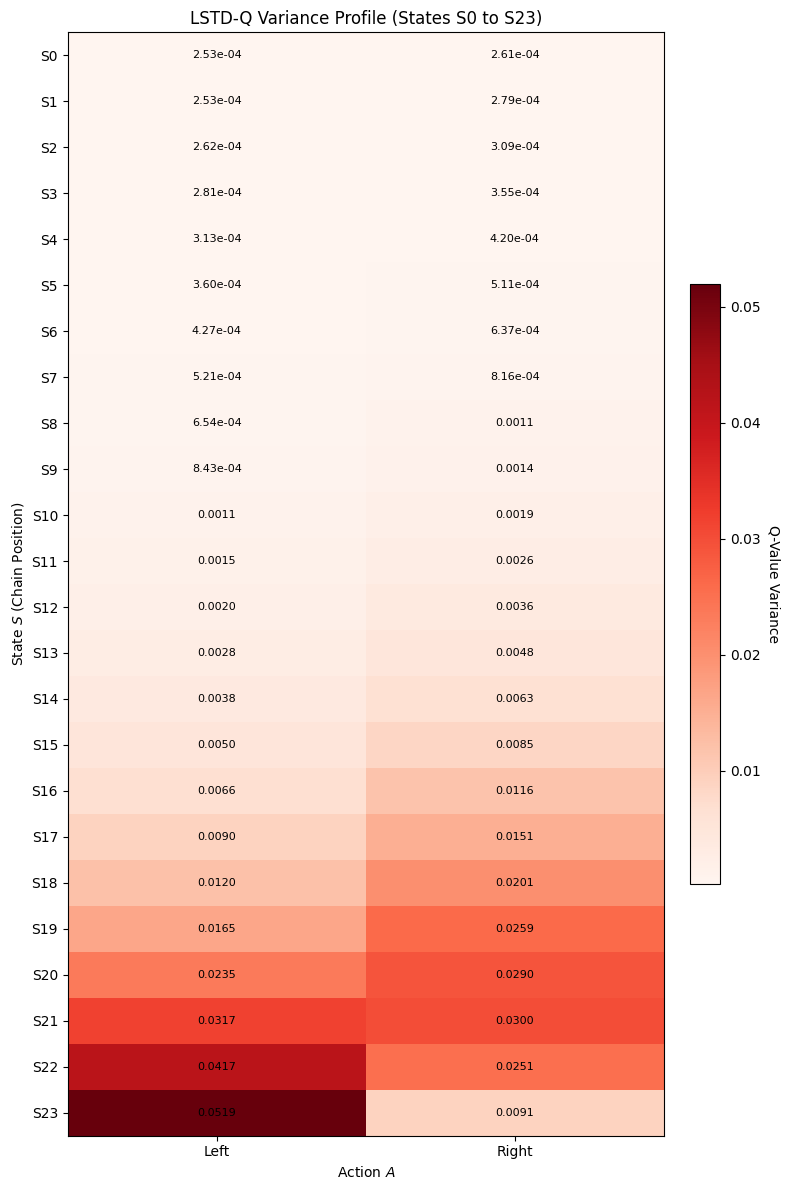

In [244]:
import pandas as pd
variance = agent.get_state_action_variance()

def visualize_chain_variance(variance_data: Dict[str, Dict[str, float]], max_clip: float = 100):
    """
    Transforms the LSTD variance output into a DataFrame and creates a heatmap 
    visualization for the Chain MDP, excluding the terminal state.
    """
    # 1. Convert Dictionary to Pandas DataFrame
    df = pd.DataFrame.from_dict(variance_data, orient='index')
    
    # 2. Identify and Remove Terminal State (Highest Index)
    
    # Get all state indices
    state_indices = {s: int(s[1:]) for s in df.index}
    
    # Find the key for the largest index (e.g., 'S24')
    terminal_state_key = max(state_indices, key=state_indices.get)
    
    # Drop the terminal state row
    df = df.drop(index=terminal_state_key, errors='ignore')
    
    # 3. Reorder Rows (States)
    # Re-extract and sort indices for the remaining states
    current_state_indices = [int(s[1:]) for s in df.index]
    df['state_index'] = current_state_indices
    df = df.sort_values(by='state_index', ascending=True)
    df = df.drop(columns=['state_index'])
    
    # 4. Clip Extreme Outliers (Safeguard remaining data)
    df_clipped = df.clip(upper=max_clip)

    # Convert DataFrame to a NumPy array for visualization
    variance_matrix = df_clipped.to_numpy()
    
    # 5. Visualization
    fig, ax = plt.subplots(figsize=(8, 12))

    # Use 'Reds' for a clear heat map
    im = ax.imshow(variance_matrix, cmap="Reds", aspect='auto')

    # 6. Setup Labels
    
    # Y-axis (States)
    ax.set_yticks(np.arange(len(df.index)))
    ax.set_yticklabels(df.index)
    
    # X-axis (Actions)
    ax.set_xticks(np.arange(len(df.columns)))
    ax.set_xticklabels(df.columns)

    ax.set_ylabel("State $S$ (Chain Position)")
    ax.set_xlabel("Action $A$")
    ax.set_title(f"LSTD-Q Variance Profile (States S0 to S{len(df.index) - 1})")

    # Add color bar
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Q-Value Variance", rotation=-90, va="bottom")

    # Annotate the heatmap with the values
    for i in range(variance_matrix.shape[0]):
        for j in range(variance_matrix.shape[1]):
            val = variance_matrix[i, j]
            if val < 0.001:
                text = ax.text(j, i, f"{val:.2e}", ha="center", va="center", color="black", fontsize=8)
            else:
                text = ax.text(j, i, f"{val:.4f}", ha="center", va="center", color="black", fontsize=8)
    
    fig.tight_layout()
    plt.show()

# Run the visualization
visualize_chain_variance(variance)

Running Chain MDP (N=25, Noise=0.25)...
EpsilonGreedyAgent
PSRLAgent
LSTDQAgent
MBIE_EB_Policy_Eval_Agent


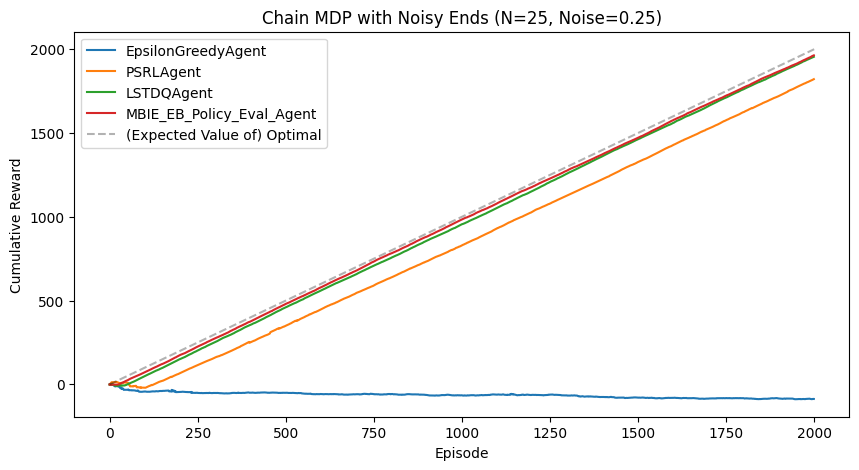

In [246]:
CHAIN_LEN = 25
NOISE = 0.25
env = ChainMDP(length=CHAIN_LEN, reward_noise_std=NOISE)
lstd_agent = LSTDQAgent(env, gamma=0.99, reg=1e-4, sigma_ema_alpha=0.05)
# Assuming EpsilonGreedyAgent is defined elsewhere and inherits from BaseAgent
eps_agent = EpsilonGreedyAgent(env, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.1)
psrl_agent = PSRLAgent(env, prior_reward_precision=1.0, prior_transition_strength=1.0, gamma=0.99)
mbie_eb_agent = MBIEEBagent(env, gamma=0.99, max_vi_iters=25)
mbie_eb_policy_eval_agent = MBIE_EB_Policy_Eval_Agent(env, gamma=0.99)
lsvi_ucb_agent = LSVIUCBAgent(env, gamma=0.99, beta=0.1, reg=1e-5)
run_noisy_chain_experiment(env, [eps_agent, psrl_agent, lstd_agent, mbie_eb_policy_eval_agent], 2000, verbose = False, random_start=False)